파일 'myown_expected.csv' 로드 완료!

=== 데이터 미리보기 ===
  Algorithm      TSPFile  StartIndex  Count  AverageTime(ms)  \
0     myown     a280.tsp           0    280              3.5   
1     myown   ar9152.tsp           0   9152           1415.0   
2     myown  bm33708.tsp           0  33708          16248.5   
3     myown   ca4663.tsp           0   4663            399.0   
4     myown  ch71009.tsp           0  71009          76146.5   

   AverageMemory(MB)  AverageResult  ExactResult  
0               3.62           2946         2579  
1               5.11         985652       837479  
2               9.72        1118462       959304  
3               4.30        1532283      1290319  
4              16.49        5249849      4566563  

총 데이터 개수: 30개


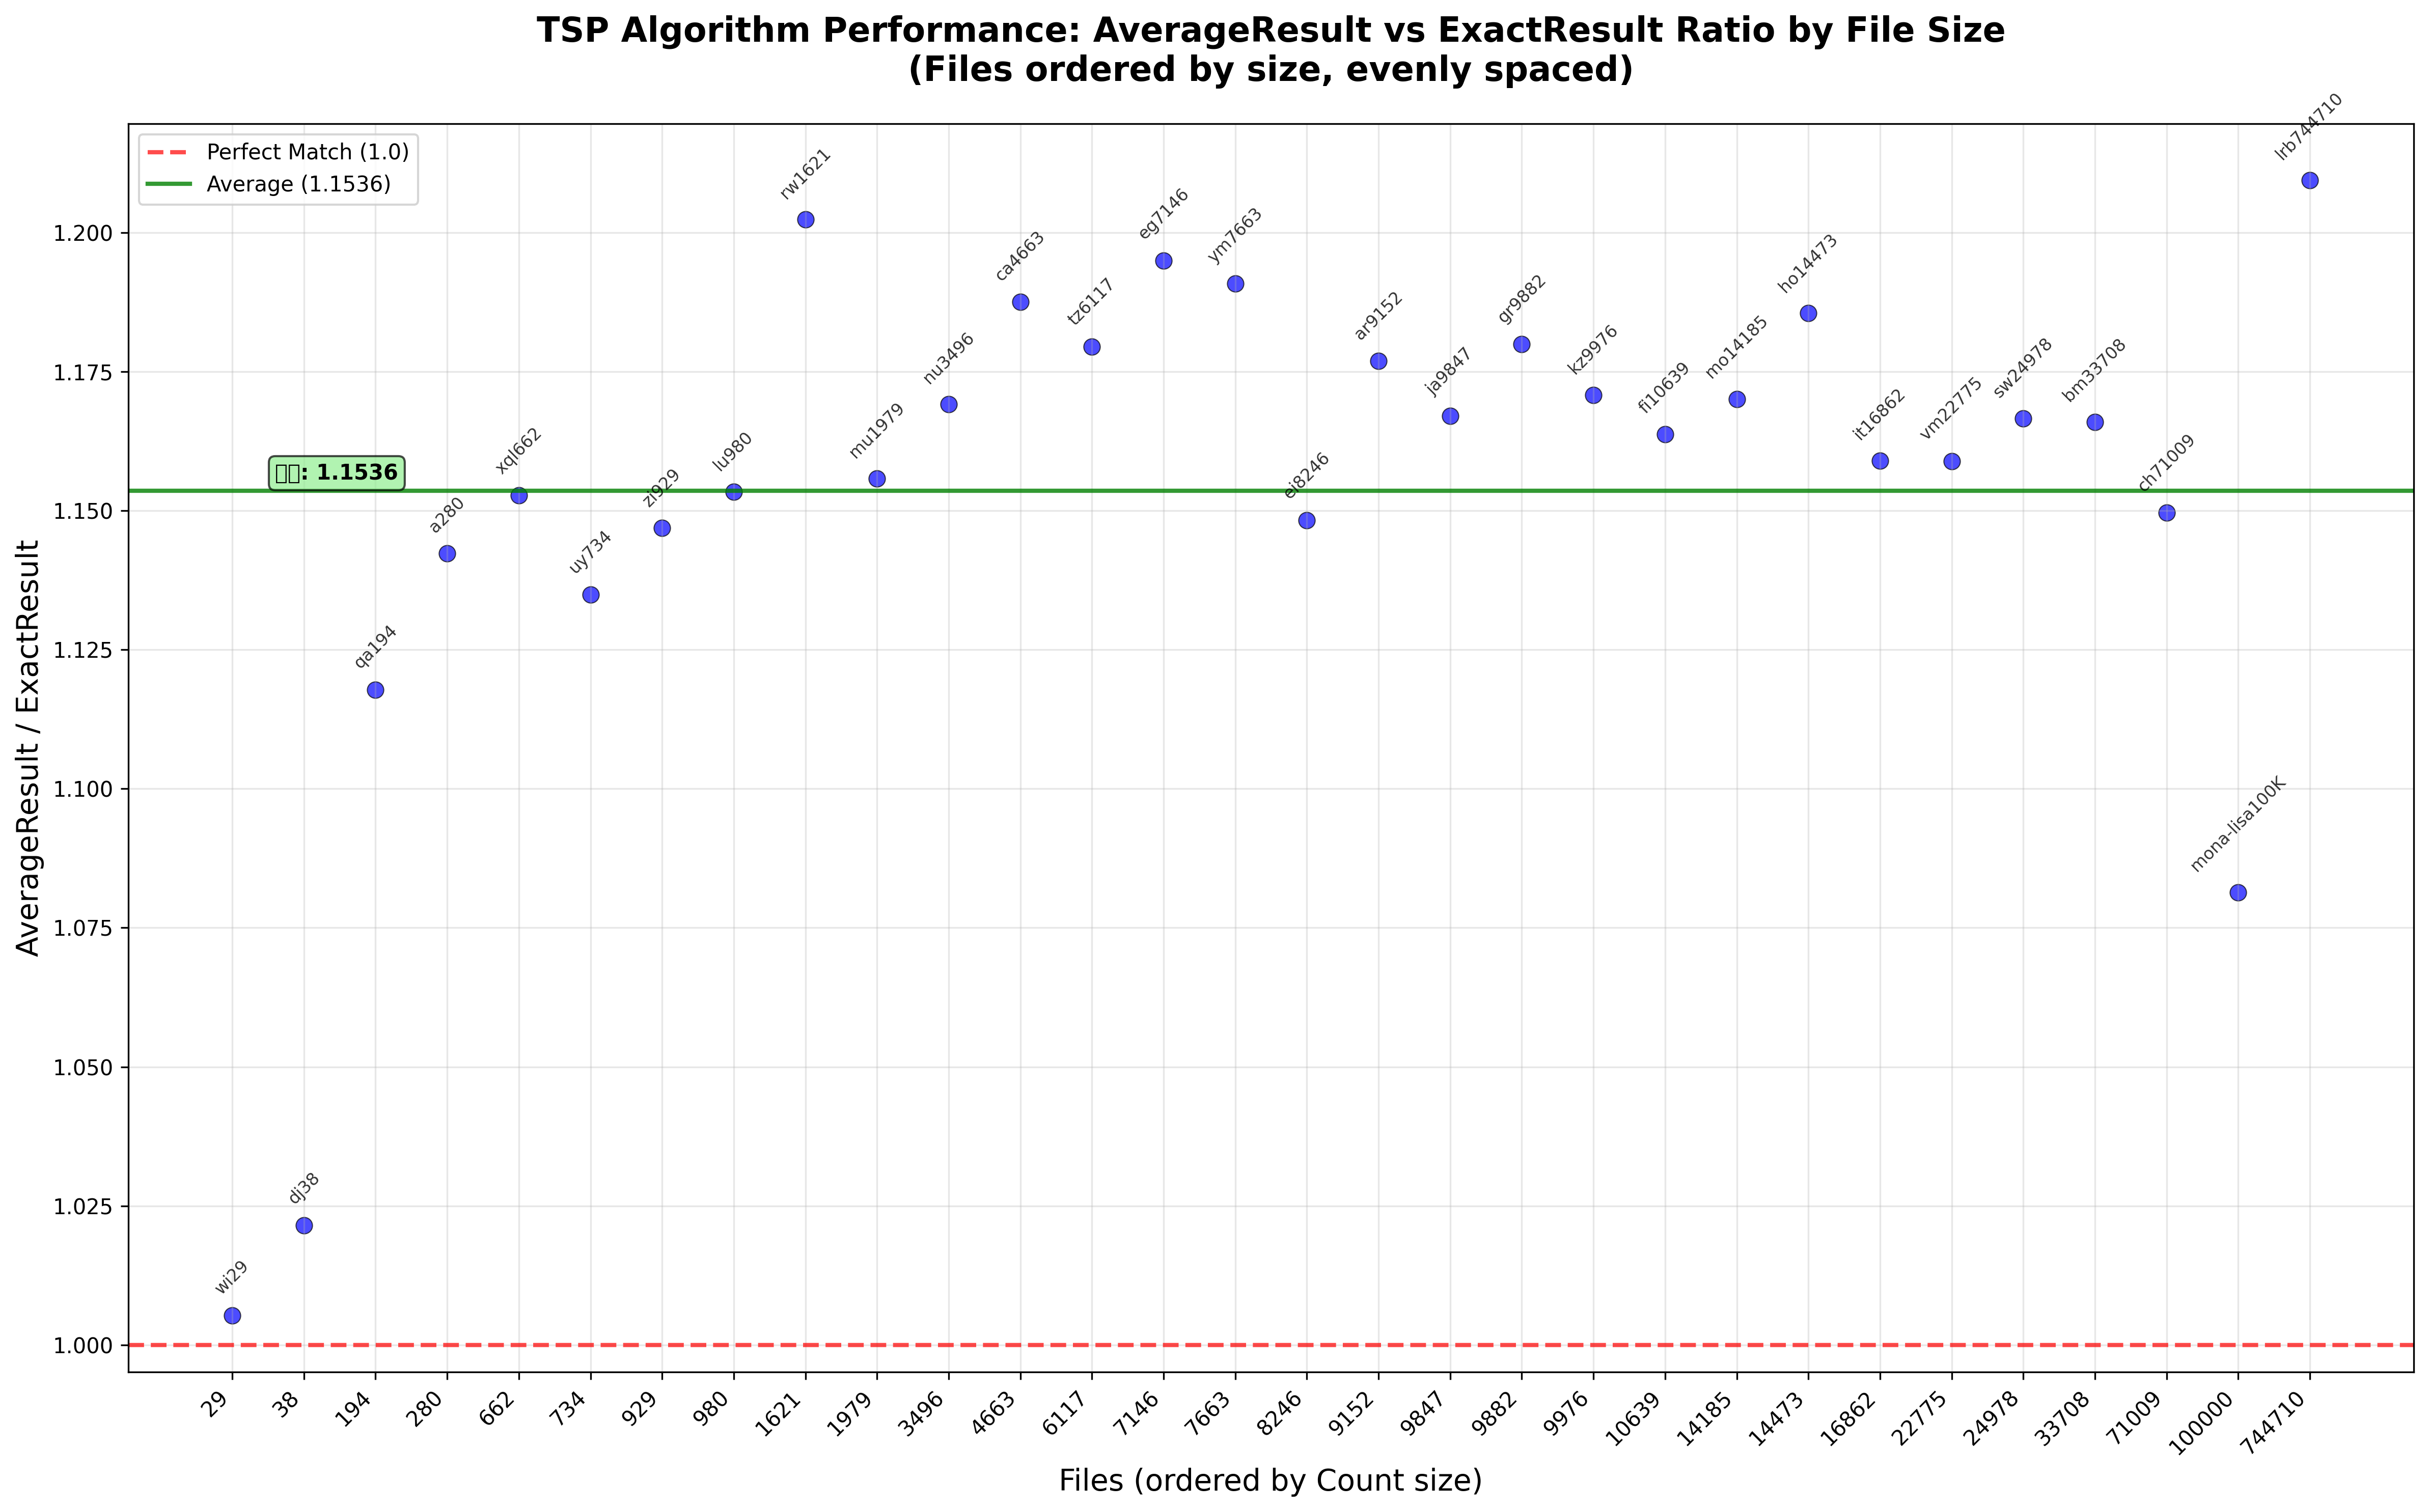

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== 상세 분석 결과 ===
평균 비율: 1.1536
중간값: 1.1648
최소 비율: 1.0053 (파일: wi29.tsp)
최대 비율: 1.2094 (파일: lrb744710.tsp)
표준편차: 0.0457

=== 평균 대비 성능 분석 ===
평균보다 높은 파일 (성능 낮음): 19개 (63.3%)
평균보다 낮은 파일 (성능 높음): 11개 (36.7%)

=== 평균에서 가장 멀리 떨어진 파일들 ===
  wi29.tsp: 1.0053 (평균 대비 낮음, 차이: 0.1483)
  dj38.tsp: 1.0215 (평균 대비 낮음, 차이: 0.1321)
  mona-lisa100K.tsp: 1.0814 (평균 대비 낮음, 차이: 0.0722)

=== 파일 크기 범위 ===
최소 파일 크기: 29 (파일: wi29.tsp)
최대 파일 크기: 744,710 (파일: lrb744710.tsp)
크기 비율: 25679.7배 차이

=== 성능 분석 ===
성능이 가장 좋은 파일 (정확도 높음):
  wi29.tsp: 1.0053 (크기: 29)
  dj38.tsp: 1.0215 (크기: 38)
  mona-lisa100K.tsp: 1.0814 (크기: 100,000)

성능이 가장 나쁜 파일 (정확도 낮음):
  lrb744710.tsp: 1.2094 (크기: 744,710)
  rw1621.tsp: 1.2024 (크기: 1,621)
  eg7146.tsp: 1.1950 (크기: 7,146)

=== 파일 크기별 성능 경향 ===
소형 파일 (<1,000): 8개, 평균 비율 1.1094
중형 파일 (1,000-10,000): 12개, 평균 비율 1.1769
대형 파일 (>=10,000): 10개, 평균 비율 1.1610


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

# 파일명 설정 (여기서 변경하세요)
file_name = 'myown_expected.csv'

# CSV 파일 읽기
try:
    df = pd.read_csv(file_name)
    print(f"파일 '{file_name}' 로드 완료!")
except FileNotFoundError:
    print(f"파일 '{file_name}'을 찾을 수 없습니다. 파일명을 확인해주세요.")
    exit()

# 데이터 확인
print("\n=== 데이터 미리보기 ===")
print(df.head())
print(f"\n총 데이터 개수: {len(df)}개")

# 비율 계산: (AverageResult / ExactResult)
df['Ratio'] = (df['AverageResult'] / df['ExactResult'])

# Count 기준으로 정렬
df_sorted = df.sort_values('Count').reset_index(drop=True)

# x축 위치를 균등하게 설정 (0, 1, 2, 3, ...)
x_positions = np.arange(len(df_sorted))

# y축 범위 및 평균 계산
y_min = df_sorted['Ratio'].min()
y_max = df_sorted['Ratio'].max()
y_mean = df_sorted['Ratio'].mean()
y_range = y_max - y_min
y_margin = y_range * 0.05  # 5% 여백 추가

# 고해상도 그래프 생성
plt.figure(figsize=(16, 10), dpi=300)

# 산점도 그래프 (균등한 간격으로)
plt.scatter(x_positions, df_sorted['Ratio'], color='blue', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

# 각 점에 파일명 표시
for i, (pos, row) in enumerate(zip(x_positions, df_sorted.itertuples())):
    plt.annotate(row.TSPFile.replace('.tsp', ''),
                (pos, row.Ratio),
                xytext=(0, 10), textcoords='offset points',
                fontsize=8, alpha=0.8, ha='center', rotation=45)

# 그래프 스타일링
plt.title('TSP Algorithm Performance: AverageResult vs ExactResult Ratio by File Size\n(Files ordered by size, evenly spaced)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Files (ordered by Count size)', fontsize=14)
plt.ylabel('AverageResult / ExactResult', fontsize=14)
plt.grid(True, alpha=0.3)

# x축 틱을 실제 Count 값으로 설정하되 균등한 간격으로 표시
plt.xticks(x_positions, df_sorted['Count'], rotation=45, ha='right')

# y축 범위를 데이터에 맞춰 설정
plt.ylim(y_min - y_margin, y_max + y_margin)

# 기준선들 추가
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Perfect Match (1.0)', linewidth=2)
plt.axhline(y=y_mean, color='green', linestyle='-', alpha=0.8, label=f'Average ({y_mean:.4f})', linewidth=2)

# 평균값을 그래프에 텍스트로 표시
plt.text(len(x_positions) * 0.02, y_mean + y_range * 0.01,
         f'평균: {y_mean:.4f}',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7),
         fontsize=10, fontweight='bold')

plt.legend()

# 레이아웃 조정
plt.tight_layout()

# 파일로 저장
output_filename = 'myown_ratio.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')

# 그래프 표시
plt.show()

# Google Colab에서 파일 다운로드
files.download(output_filename)

# 상세 통계 정보 출력
print(f"\n=== 상세 분석 결과 ===")
print(f"평균 비율: {df['Ratio'].mean():.4f}")
print(f"중간값: {df['Ratio'].median():.4f}")
print(f"최소 비율: {df['Ratio'].min():.4f} (파일: {df.loc[df['Ratio'].idxmin(), 'TSPFile']})")
print(f"최대 비율: {df['Ratio'].max():.4f} (파일: {df.loc[df['Ratio'].idxmax(), 'TSPFile']})")
print(f"표준편차: {df['Ratio'].std():.4f}")

# 평균 대비 성능 분석
above_average = df[df['Ratio'] > y_mean]
below_average = df[df['Ratio'] < y_mean]
at_average = df[df['Ratio'] == y_mean]

print(f"\n=== 평균 대비 성능 분석 ===")
print(f"평균보다 높은 파일 (성능 낮음): {len(above_average)}개 ({len(above_average)/len(df)*100:.1f}%)")
print(f"평균보다 낮은 파일 (성능 높음): {len(below_average)}개 ({len(below_average)/len(df)*100:.1f}%)")
if len(at_average) > 0:
    print(f"평균과 동일한 파일: {len(at_average)}개")

# 평균에서 가장 멀리 떨어진 파일들
print(f"\n=== 평균에서 가장 멀리 떨어진 파일들 ===")
df['Distance_from_mean'] = abs(df['Ratio'] - y_mean)
farthest_files = df.nlargest(3, 'Distance_from_mean')[['TSPFile', 'Count', 'Ratio', 'Distance_from_mean']]

for _, row in farthest_files.iterrows():
    direction = "높음" if row['Ratio'] > y_mean else "낮음"
    print(f"  {row['TSPFile']}: {row['Ratio']:.4f} (평균 대비 {direction}, 차이: {row['Distance_from_mean']:.4f})")

# 파일 크기 범위 정보
print(f"\n=== 파일 크기 범위 ===")
print(f"최소 파일 크기: {df['Count'].min():,} (파일: {df.loc[df['Count'].idxmin(), 'TSPFile']})")
print(f"최대 파일 크기: {df['Count'].max():,} (파일: {df.loc[df['Count'].idxmax(), 'TSPFile']})")
print(f"크기 비율: {df['Count'].max() / df['Count'].min():.1f}배 차이")

# 성능이 좋은 파일과 나쁜 파일 분석
print(f"\n=== 성능 분석 ===")
best_files = df.nsmallest(3, 'Ratio')[['TSPFile', 'Count', 'Ratio']]
worst_files = df.nlargest(3, 'Ratio')[['TSPFile', 'Count', 'Ratio']]

print("성능이 가장 좋은 파일 (정확도 높음):")
for _, row in best_files.iterrows():
    print(f"  {row['TSPFile']}: {row['Ratio']:.4f} (크기: {row['Count']:,})")

print("\n성능이 가장 나쁜 파일 (정확도 낮음):")
for _, row in worst_files.iterrows():
    print(f"  {row['TSPFile']}: {row['Ratio']:.4f} (크기: {row['Count']:,})")

# 파일 크기별 성능 경향 분석
print(f"\n=== 파일 크기별 성능 경향 ===")
small_files = df[df['Count'] < 1000]
medium_files = df[(df['Count'] >= 1000) & (df['Count'] < 10000)]
large_files = df[df['Count'] >= 10000]

if len(small_files) > 0:
    print(f"소형 파일 (<1,000): {len(small_files)}개, 평균 비율 {small_files['Ratio'].mean():.4f}")
if len(medium_files) > 0:
    print(f"중형 파일 (1,000-10,000): {len(medium_files)}개, 평균 비율 {medium_files['Ratio'].mean():.4f}")
if len(large_files) > 0:
    print(f"대형 파일 (>=10,000): {len(large_files)}개, 평균 비율 {large_files['Ratio'].mean():.4f}")


파일 'HK_1-25.csv' 로드 완료!

=== 데이터 미리보기 ===
  Algorithm            TSPFile  StartIndex  Count  AverageTime(ms)  \
0  basic_HK           a280.tsp           0      1              0.0   
1  basic_HK         xql662.tsp           0      1              0.0   
2  basic_HK         kz9976.tsp           0      1              0.0   
3  basic_HK  mona-lisa100K.tsp           0      1              0.0   
4  basic_HK           a280.tsp           0      2              0.0   

   AverageMemory(MB)  AverageResult  
0               3.55              0  
1               3.62              0  
2               3.58              0  
3               3.58              0  
4               3.60             40  

총 데이터 개수: 100개

=== TSP 파일 목록 ===
1. a280.tsp: 25개 데이터 포인트
2. xql662.tsp: 25개 데이터 포인트
3. kz9976.tsp: 25개 데이터 포인트
4. mona-lisa100K.tsp: 25개 데이터 포인트


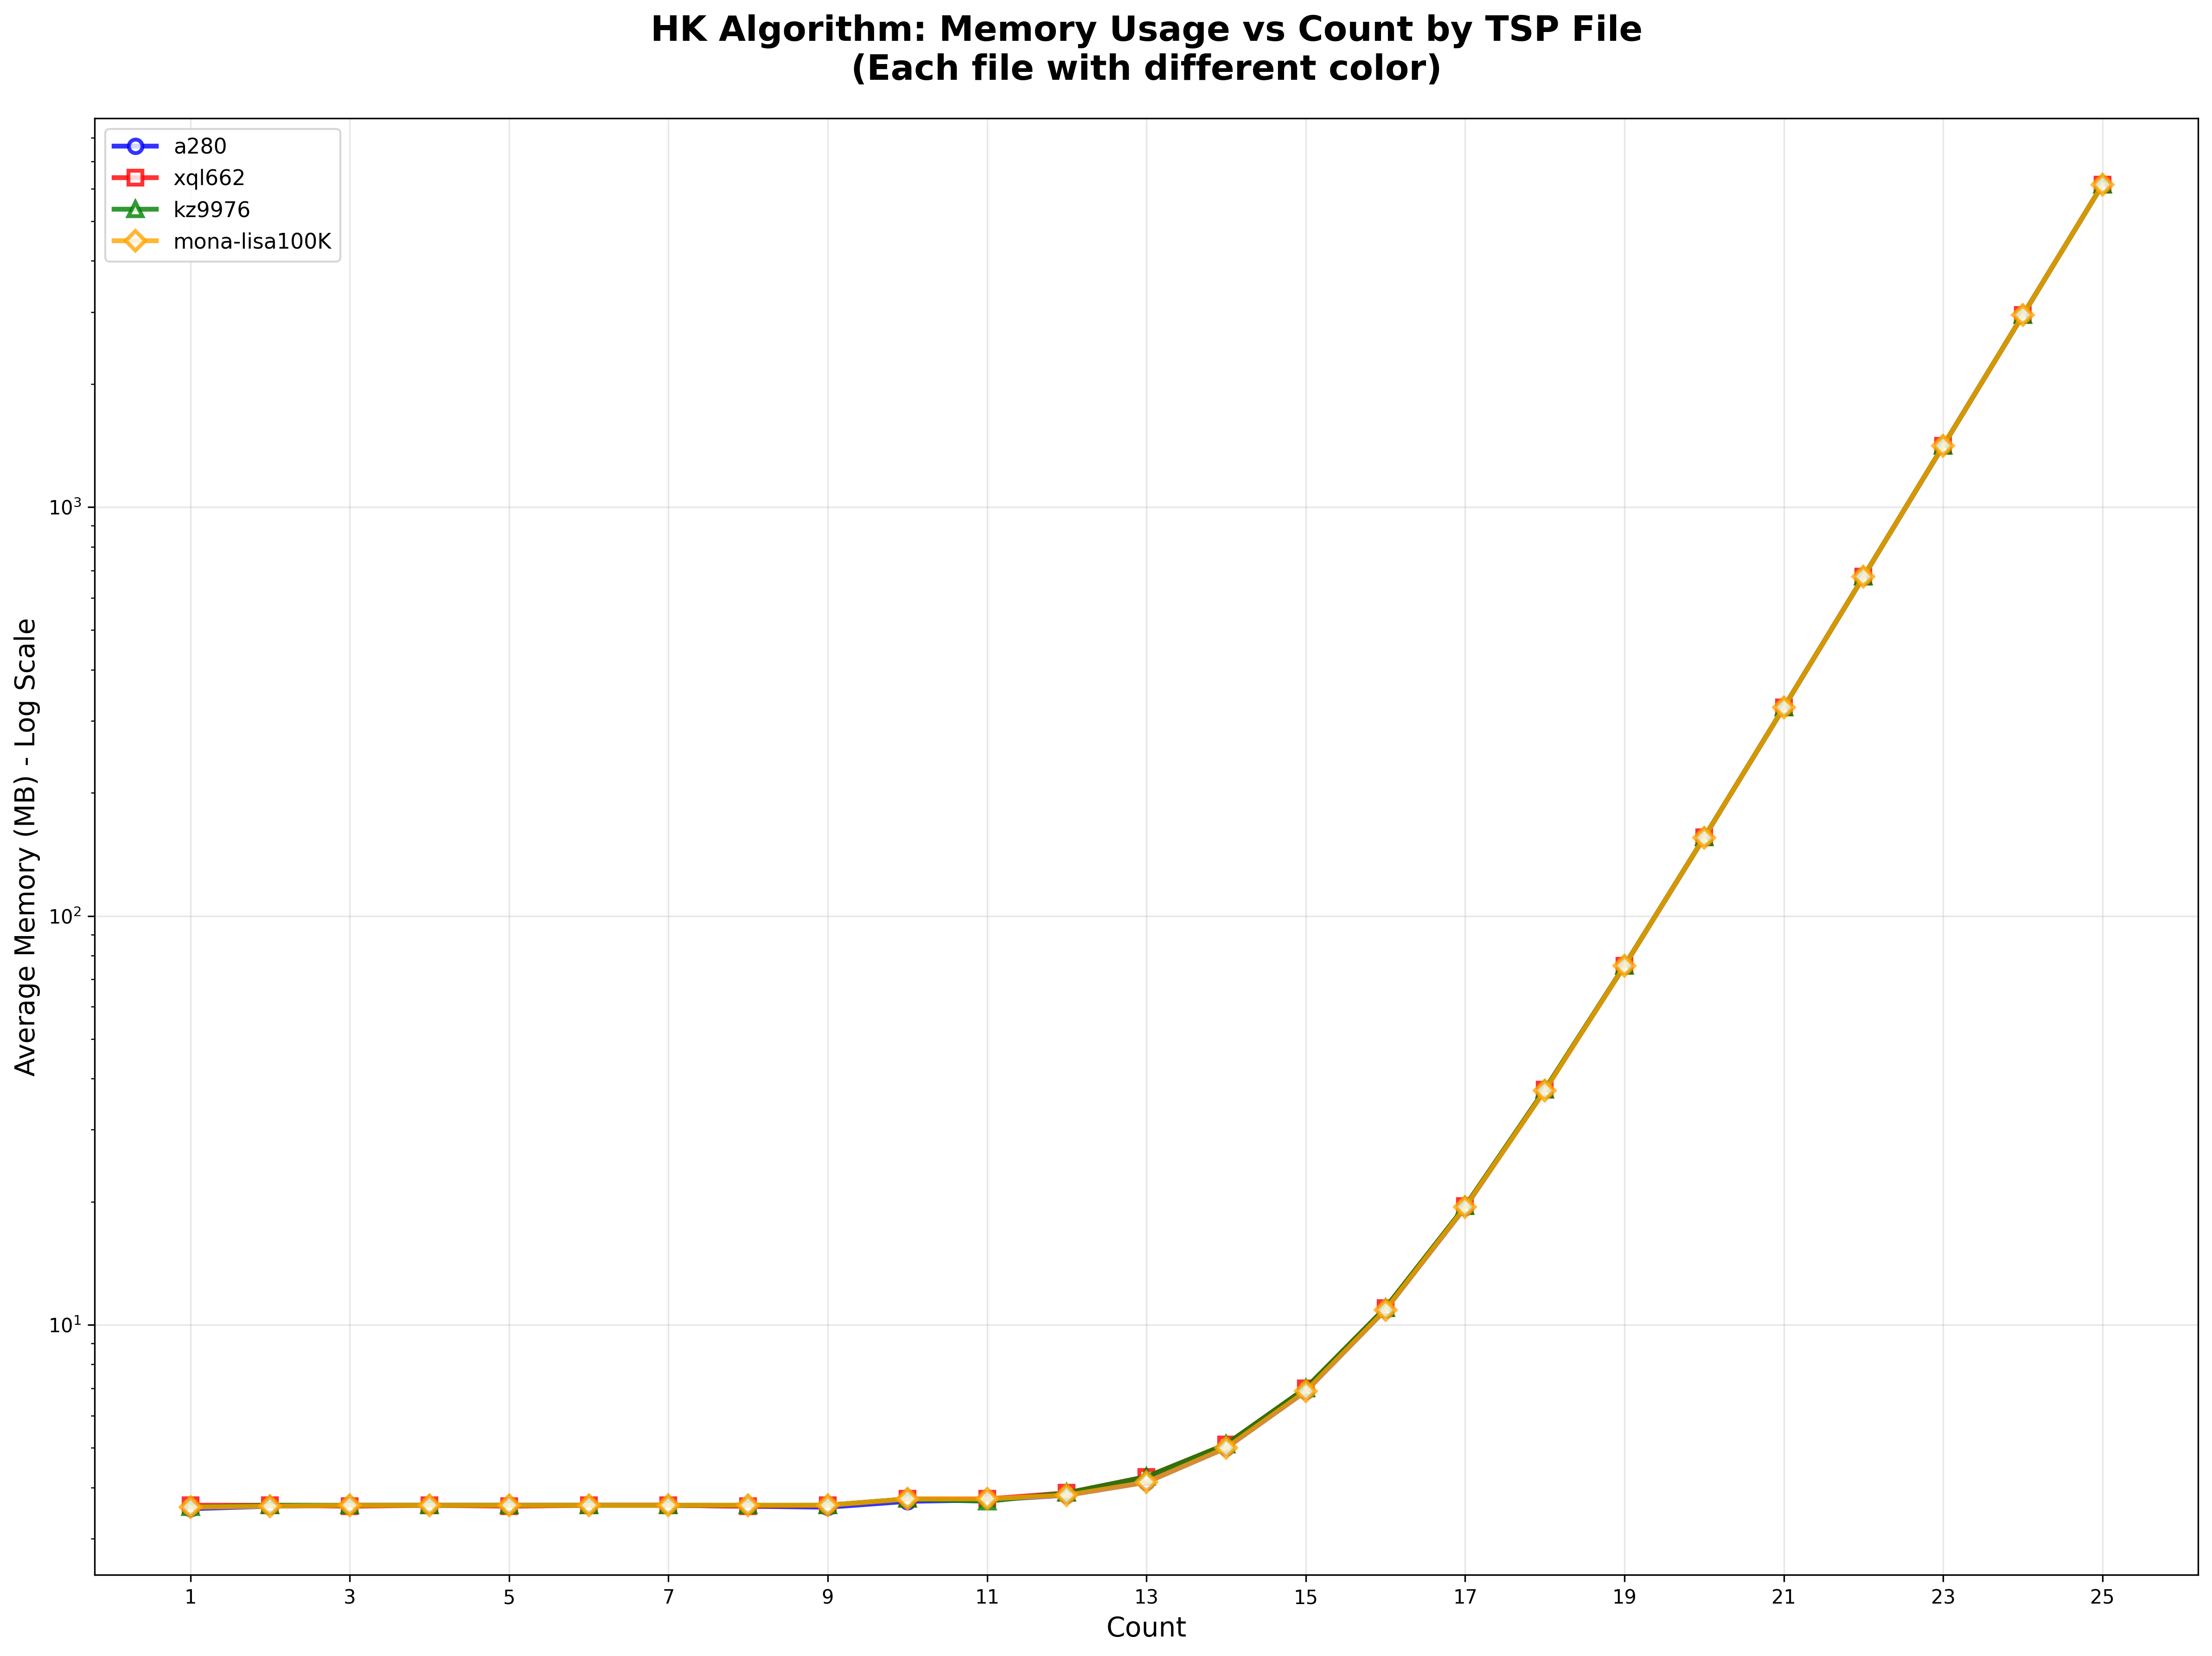

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== 파일별 메모리 사용량 분석 ===

a280.tsp:
  최소 메모리: 3.55 MB (Count: 1)
  최대 메모리: 6147.50 MB (Count: 25)
  메모리 증가 비율: 1731.7배

xql662.tsp:
  최소 메모리: 3.60 MB (Count: 1)
  최대 메모리: 6147.57 MB (Count: 25)
  메모리 증가 비율: 1707.7배

kz9976.tsp:
  최소 메모리: 3.58 MB (Count: 1)
  최대 메모리: 6147.60 MB (Count: 25)
  메모리 증가 비율: 1717.2배

mona-lisa100K.tsp:
  최소 메모리: 3.58 MB (Count: 1)
  최대 메모리: 6147.48 MB (Count: 25)
  메모리 증가 비율: 1717.2배

=== Count 25에서의 파일별 메모리 사용량 ===
kz9976.tsp: 6,147.60 MB
xql662.tsp: 6,147.57 MB
a280.tsp: 6,147.50 MB
mona-lisa100K.tsp: 6,147.48 MB

=== 메모리 효율성 분석 (Count 25 기준) ===
메모리 효율성 순위 (낮을수록 효율적):
1. mona-lisa100K.tsp: 245.90 MB/Count
2. a280.tsp: 245.90 MB/Count
3. xql662.tsp: 245.90 MB/Count
4. kz9976.tsp: 245.90 MB/Count

=== 메모리 증가 패턴 분석 ===
a280.tsp: 지수적 증가 (가속도: 67657.1배)
kz9976.tsp: 지수적 증가 (가속도: 118400.0배)
mona-lisa100K.tsp: 지수적 증가 (가속도: 118400.7배)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

# 파일명 설정
file_name = 'HK_1-25.csv'

# CSV 파일 읽기
try:
    df = pd.read_csv(file_name)
    print(f"파일 '{file_name}' 로드 완료!")
except FileNotFoundError:
    print(f"파일 '{file_name}'을 찾을 수 없습니다. 파일명을 확인해주세요.")
    exit()

# 데이터 확인
print("\n=== 데이터 미리보기 ===")
print(df.head())
print(f"\n총 데이터 개수: {len(df)}개")

# TSP 파일별로 고유한 파일 목록 확인
unique_files = df['TSPFile'].unique()
print(f"\n=== TSP 파일 목록 ===")
for i, file in enumerate(unique_files):
    file_data = df[df['TSPFile'] == file]
    print(f"{i+1}. {file}: {len(file_data)}개 데이터 포인트")

# 색상 팔레트 설정 (각 파일별로 다른 색상)
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# 고해상도 그래프 생성
plt.figure(figsize=(16, 12), dpi=300)

# 각 TSP 파일별로 선 그래프 그리기
for i, tsp_file in enumerate(unique_files):
    # 해당 파일의 데이터만 필터링
    file_data = df[df['TSPFile'] == tsp_file].sort_values('Count')

    # x축과 y축 데이터
    x_data = file_data['Count']
    y_data = file_data['AverageMemory(MB)']

    # 색상과 마커 선택 (순환)
    color = colors[i % len(colors)]
    marker = markers[i % len(markers)]

    # 선 그래프 그리기
    plt.plot(x_data, y_data,
             marker=marker, linestyle='-', color=color,
             alpha=0.8, linewidth=2.5, markersize=7,
             markerfacecolor='white', markeredgecolor=color,
             markeredgewidth=2, label=tsp_file.replace('.tsp', ''))

# 그래프 스타일링
plt.title('HK Algorithm: Memory Usage vs Count by TSP File\n(Each file with different color)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Average Memory (MB)', fontsize=14)
plt.grid(True, alpha=0.3)

# 범례 설정 (파일이 많을 경우 2열로 표시)
if len(unique_files) > 6:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize=10)
else:
    plt.legend(fontsize=11, loc='upper left')

# y축을 로그 스케일로 설정 (메모리 사용량이 급격히 증가하므로)
plt.yscale('log')
plt.ylabel('Average Memory (MB) - Log Scale', fontsize=14)

# x축 틱 설정
plt.xticks(range(1, 26, 2))  # 1, 3, 5, 7, ... 25

# 레이아웃 조정
plt.tight_layout()

# 파일로 저장
output_filename = 'hk_mem.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')

# 그래프 표시
plt.show()

# Google Colab에서 파일 다운로드
files.download(output_filename)

# 각 파일별 상세 분석
print(f"\n=== 파일별 메모리 사용량 분석 ===")
for tsp_file in unique_files:
    file_data = df[df['TSPFile'] == tsp_file].sort_values('Count')
    min_memory = file_data['AverageMemory(MB)'].min()
    max_memory = file_data['AverageMemory(MB)'].max()
    growth_ratio = max_memory / min_memory if min_memory > 0 else float('inf')

    print(f"\n{tsp_file}:")
    print(f"  최소 메모리: {min_memory:.2f} MB (Count: {file_data.iloc[0]['Count']})")
    print(f"  최대 메모리: {max_memory:.2f} MB (Count: {file_data.iloc[-1]['Count']})")
    print(f"  메모리 증가 비율: {growth_ratio:.1f}배")

# Count 25에서의 파일별 메모리 사용량 비교
print(f"\n=== Count 25에서의 파일별 메모리 사용량 ===")
count_25_data = df[df['Count'] == 25].sort_values('AverageMemory(MB)', ascending=False)
for _, row in count_25_data.iterrows():
    print(f"{row['TSPFile']}: {row['AverageMemory(MB)']:,.2f} MB")

# 메모리 효율성 분석 (Count 대비 메모리 사용량)
print(f"\n=== 메모리 효율성 분석 (Count 25 기준) ===")
efficiency_data = []
for _, row in count_25_data.iterrows():
    efficiency = row['AverageMemory(MB)'] / 25  # MB per Count
    efficiency_data.append((row['TSPFile'], efficiency))

efficiency_data.sort(key=lambda x: x[1])
print("메모리 효율성 순위 (낮을수록 효율적):")
for i, (file, eff) in enumerate(efficiency_data):
    print(f"{i+1}. {file}: {eff:.2f} MB/Count")

# 선형 vs 지수적 증가 패턴 분석
print(f"\n=== 메모리 증가 패턴 분석 ===")
for tsp_file in unique_files:
    file_data = df[df['TSPFile'] == tsp_file].sort_values('Count')
    if len(file_data) >= 3:
        # 처음과 마지막 3개 데이터 포인트의 증가율 비교
        early_growth = (file_data.iloc[2]['AverageMemory(MB)'] - file_data.iloc[0]['AverageMemory(MB)']) / 2
        late_growth = (file_data.iloc[-1]['AverageMemory(MB)'] - file_data.iloc[-3]['AverageMemory(MB)']) / 2

        if early_growth > 0:
            acceleration = late_growth / early_growth
            pattern = "지수적 증가" if acceleration > 10 else "선형적 증가" if acceleration < 3 else "중간 증가"
            print(f"{tsp_file}: {pattern} (가속도: {acceleration:.1f}배)")


파일 'HK_1-25.csv' 로드 완료!

=== 데이터 미리보기 ===
  Algorithm            TSPFile  StartIndex  Count  AverageTime(ms)  \
0  basic_HK           a280.tsp           0      1              0.0   
1  basic_HK         xql662.tsp           0      1              0.0   
2  basic_HK         kz9976.tsp           0      1              0.0   
3  basic_HK  mona-lisa100K.tsp           0      1              0.0   
4  basic_HK           a280.tsp           0      2              0.0   

   AverageMemory(MB)  AverageResult  
0               3.55              0  
1               3.62              0  
2               3.58              0  
3               3.58              0  
4               3.60             40  

총 데이터 개수: 100개

=== TSP 파일 목록 ===
1. a280.tsp: 25개 데이터 포인트
2. xql662.tsp: 25개 데이터 포인트
3. kz9976.tsp: 25개 데이터 포인트
4. mona-lisa100K.tsp: 25개 데이터 포인트

=== a280.tsp 함수 피팅 결과 ===
Linear      : R² = 0.301838, y = 100.4229x + -830.9460
Quadratic   : R² = 0.614984, y = 15.8971x² + -312.9020x + 1029.0161
Exponential

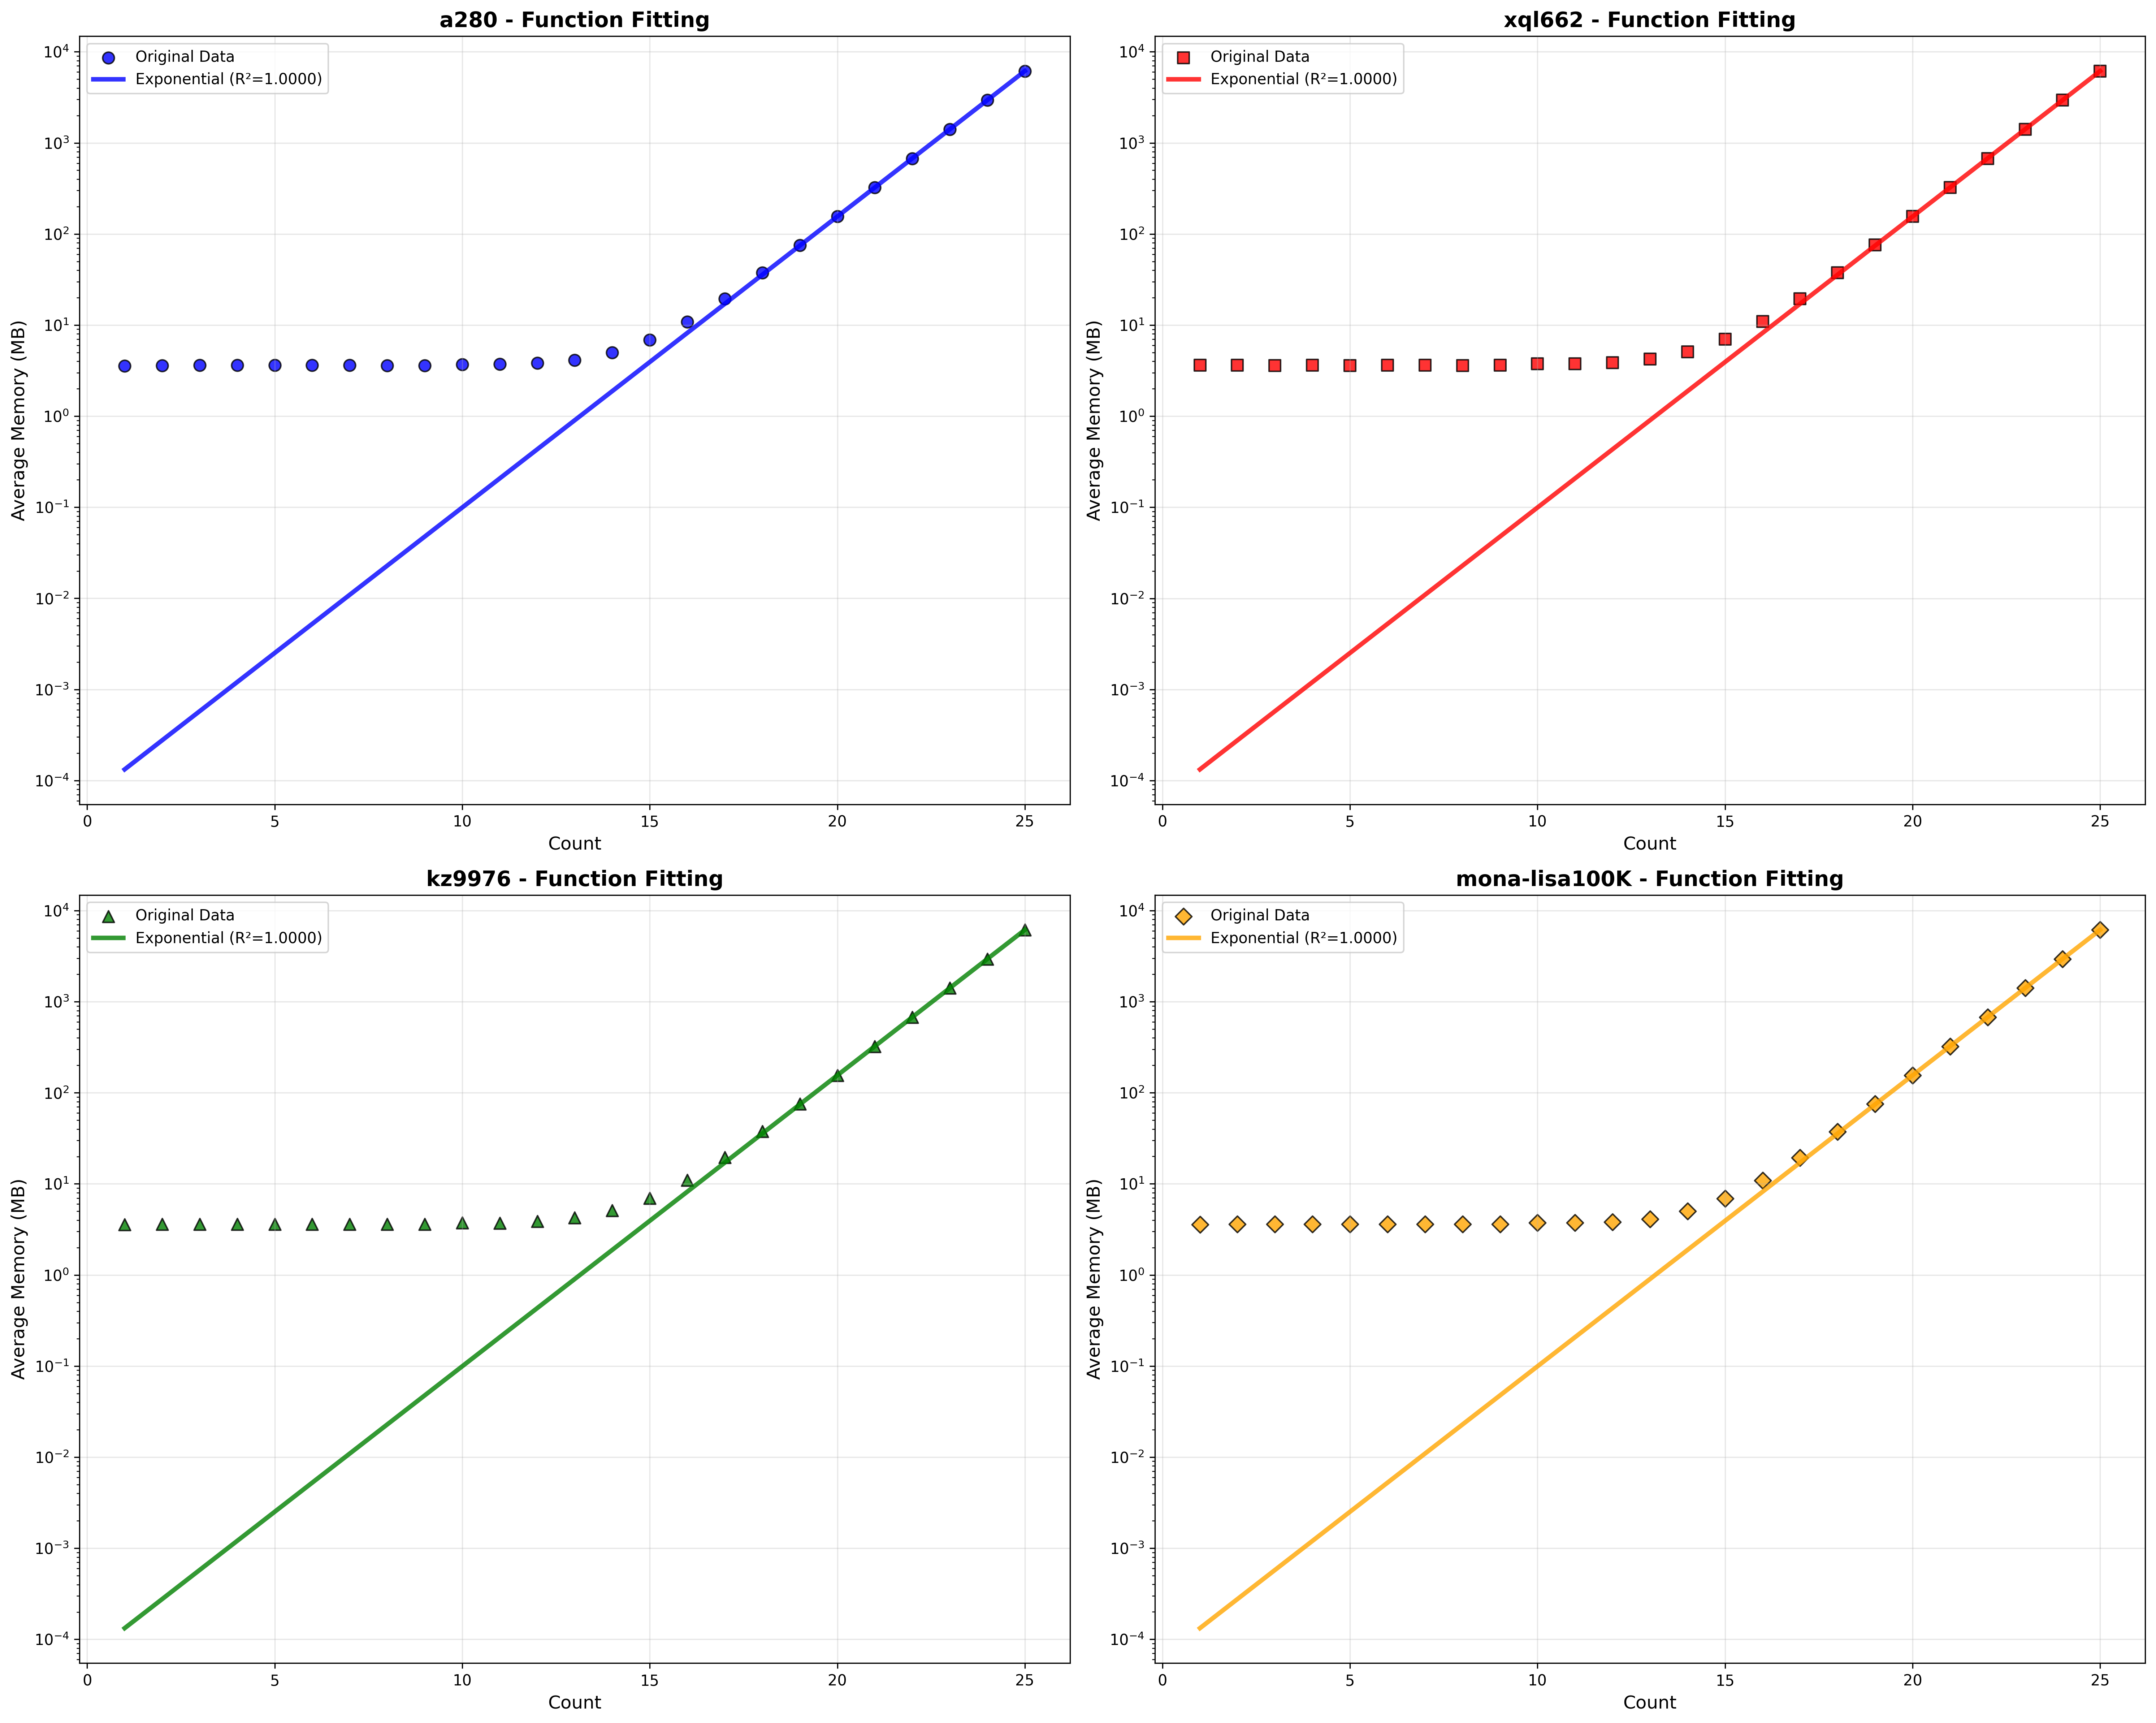

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== 종합 함수 피팅 분석 결과 ===

a280.tsp:
  최적 함수: Exponential
  R² 점수: 0.999995
  수식: y = 0.0001 * e^(0.7355x)
  전체 모델 성능:
    Linear      : R² = 0.301838
    Quadratic   : R² = 0.614984
    Exponential : R² = 0.999995
    Power       : R² = 0.999838
    Logarithmic : R² = 0.141296
    Polynomial_3: R² = 0.831423

xql662.tsp:
  최적 함수: Exponential
  R² 점수: 0.999995
  수식: y = 0.0001 * e^(0.7355x)
  전체 모델 성능:
    Linear      : R² = 0.301871
    Quadratic   : R² = 0.615008
    Exponential : R² = 0.999995
    Power       : R² = 0.999837
    Logarithmic : R² = 0.141315
    Polynomial_3: R² = 0.831426

kz9976.tsp:
  최적 함수: Exponential
  R² 점수: 0.999995
  수식: y = 0.0001 * e^(0.7355x)
  전체 모델 성능:
    Linear      : R² = 0.301867
    Quadratic   : R² = 0.615002
    Exponential : R² = 0.999995
    Power       : R² = 0.999837
    Logarithmic : R² = 0.141314
    Polynomial_3: R² = 0.831423

mona-lisa100K.tsp:
  최적 함수: Exponential
  R² 점수: 0.999995
  수식: y = 0.0001 * e^(0.7355x)
  전체 모델 성능:
    Linear     

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# 파일명 설정
file_name = 'HK_1-25.csv'

# CSV 파일 읽기
try:
    df = pd.read_csv(file_name)
    print(f"파일 '{file_name}' 로드 완료!")
except FileNotFoundError:
    print(f"파일 '{file_name}'을 찾을 수 없습니다. 파일명을 확인해주세요.")
    exit()

# 데이터 확인
print("\n=== 데이터 미리보기 ===")
print(df.head())
print(f"\n총 데이터 개수: {len(df)}개")

# 함수 모델들 정의
def linear_func(x, a, b):
    """선형 함수: y = ax + b"""
    return a * x + b

def quadratic_func(x, a, b, c):
    """이차 함수: y = ax² + bx + c"""
    return a * x**2 + b * x + c

def exponential_func(x, a, b):
    """지수 함수: y = a * e^(bx)"""
    return a * np.exp(b * x)

def power_func(x, a, b):
    """거듭제곱 함수: y = a * x^b"""
    return a * np.power(x, b)

def logarithmic_func(x, a, b):
    """로그 함수: y = a * ln(x) + b"""
    return a * np.log(x) + b

def polynomial_3_func(x, a, b, c, d):
    """3차 다항식: y = ax³ + bx² + cx + d"""
    return a * x**3 + b * x**2 + c * x + d

# TSP 파일별로 고유한 파일 목록 확인
unique_files = df['TSPFile'].unique()
print(f"\n=== TSP 파일 목록 ===")
for i, file in enumerate(unique_files):
    file_data = df[df['TSPFile'] == file]
    print(f"{i+1}. {file}: {len(file_data)}개 데이터 포인트")

# 색상 팔레트 설정
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

# 함수 피팅 결과를 저장할 딕셔너리
fitting_results = {}

# 각 TSP 파일별로 함수 피팅 수행
for i, tsp_file in enumerate(unique_files):
    file_data = df[df['TSPFile'] == tsp_file].sort_values('Count')
    x_data = file_data['Count'].values
    y_data = file_data['AverageMemory(MB)'].values

    print(f"\n=== {tsp_file} 함수 피팅 결과 ===")

    # 각 함수 모델에 대해 피팅 시도
    models = {
        'Linear': (linear_func, 'y = {:.4f}x + {:.4f}'),
        'Quadratic': (quadratic_func, 'y = {:.4f}x² + {:.4f}x + {:.4f}'),
        'Exponential': (exponential_func, 'y = {:.4f} * e^({:.4f}x)'),
        'Power': (power_func, 'y = {:.4f} * x^{:.4f}'),
        'Logarithmic': (logarithmic_func, 'y = {:.4f} * ln(x) + {:.4f}'),
        'Polynomial_3': (polynomial_3_func, 'y = {:.4f}x³ + {:.4f}x² + {:.4f}x + {:.4f}')
    }

    file_results = {}

    for model_name, (func, formula_template) in models.items():
        try:
            # 함수 피팅
            if model_name == 'Logarithmic' and np.any(x_data <= 0):
                continue  # 로그 함수는 x > 0이어야 함

            popt, pcov = curve_fit(func, x_data, y_data, maxfev=5000)

            # 예측값 계산
            y_pred = func(x_data, *popt)

            # R² 계산
            r2 = r2_score(y_data, y_pred)

            # 결과 저장
            file_results[model_name] = {
                'params': popt,
                'r2': r2,
                'func': func,
                'formula': formula_template.format(*popt)
            }

            print(f"{model_name:12}: R² = {r2:.6f}, {formula_template.format(*popt)}")

        except Exception as e:
            print(f"{model_name:12}: 피팅 실패 - {str(e)[:50]}...")

    # 가장 좋은 모델 찾기
    if file_results:
        best_model = max(file_results.items(), key=lambda x: x[1]['r2'])
        print(f"\n최적 모델: {best_model[0]} (R² = {best_model[1]['r2']:.6f})")
        print(f"수식: {best_model[1]['formula']}")

        fitting_results[tsp_file] = {
            'all_models': file_results,
            'best_model': best_model
        }

# 원본 데이터와 피팅된 함수들을 함께 시각화
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16), dpi=300)
axes = [ax1, ax2, ax3, ax4]

for i, tsp_file in enumerate(unique_files):
    if i >= 4:  # 최대 4개 파일만 표시
        break

    ax = axes[i]
    file_data = df[df['TSPFile'] == tsp_file].sort_values('Count')
    x_data = file_data['Count'].values
    y_data = file_data['AverageMemory(MB)'].values

    # 원본 데이터 플롯
    color = colors[i % len(colors)]
    marker = markers[i % len(markers)]
    ax.scatter(x_data, y_data, color=color, alpha=0.8, s=60,
               edgecolors='black', linewidth=1, label='Original Data', marker=marker)

    # 피팅된 함수들 플롯
    if tsp_file in fitting_results:
        x_smooth = np.linspace(x_data.min(), x_data.max(), 100)

        # 최적 모델만 표시
        best_model_name, best_model_info = fitting_results[tsp_file]['best_model']
        best_func = best_model_info['func']
        best_params = best_model_info['params']

        try:
            y_smooth = best_func(x_smooth, *best_params)
            ax.plot(x_smooth, y_smooth, color=color, linewidth=3, alpha=0.8,
                   label=f'{best_model_name} (R²={best_model_info["r2"]:.4f})')
        except:
            pass

    ax.set_title(f'{tsp_file.replace(".tsp", "")} - Function Fitting', fontsize=14, fontweight='bold')
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('Average Memory (MB)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_yscale('log')

plt.tight_layout()

# 파일로 저장
output_filename = 'hk_function_fitting_analysis.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Google Colab에서 파일 다운로드
files.download(output_filename)

# 종합 분석 결과 출력
print(f"\n{'='*60}")
print("=== 종합 함수 피팅 분석 결과 ===")
print(f"{'='*60}")

for tsp_file in unique_files:
    if tsp_file in fitting_results:
        print(f"\n{tsp_file}:")
        best_model_name, best_model_info = fitting_results[tsp_file]['best_model']
        print(f"  최적 함수: {best_model_name}")
        print(f"  R² 점수: {best_model_info['r2']:.6f}")
        print(f"  수식: {best_model_info['formula']}")

        # 모든 모델의 R² 점수 비교
        print("  전체 모델 성능:")
        for model_name, model_info in fitting_results[tsp_file]['all_models'].items():
            print(f"    {model_name:12}: R² = {model_info['r2']:.6f}")

# 예측 기능 추가
print(f"\n{'='*60}")
print("=== 함수를 이용한 예측 ===")
print(f"{'='*60}")

# Count 30에서의 메모리 사용량 예측
predict_count = 30
print(f"\nCount {predict_count}에서의 예상 메모리 사용량:")

for tsp_file in unique_files:
    if tsp_file in fitting_results:
        best_model_name, best_model_info = fitting_results[tsp_file]['best_model']
        best_func = best_model_info['func']
        best_params = best_model_info['params']

        try:
            predicted_memory = best_func(predict_count, *best_params)
            print(f"  {tsp_file}: {predicted_memory:,.2f} MB ({best_model_name} 모델)")
        except:
            print(f"  {tsp_file}: 예측 불가 ({best_model_name} 모델)")

print(f"\n{'='*60}")
print("함수 피팅 분석이 완료되었습니다!")
print(f"{'='*60}")


=== 데이터 로드 완료 ===
CH 데이터: 4개
myown 데이터: 5개
MST2 데이터: 5개

파일 정렬 순서 (Count 기준): ['a280.tsp', 'xql662.tsp', 'kz9976.tsp', 'it16862.tsp', 'mona-lisa100K.tsp']
AverageTime(ms): 로그 스케일 적용 (범위: 2.00 ~ 66207403.00)


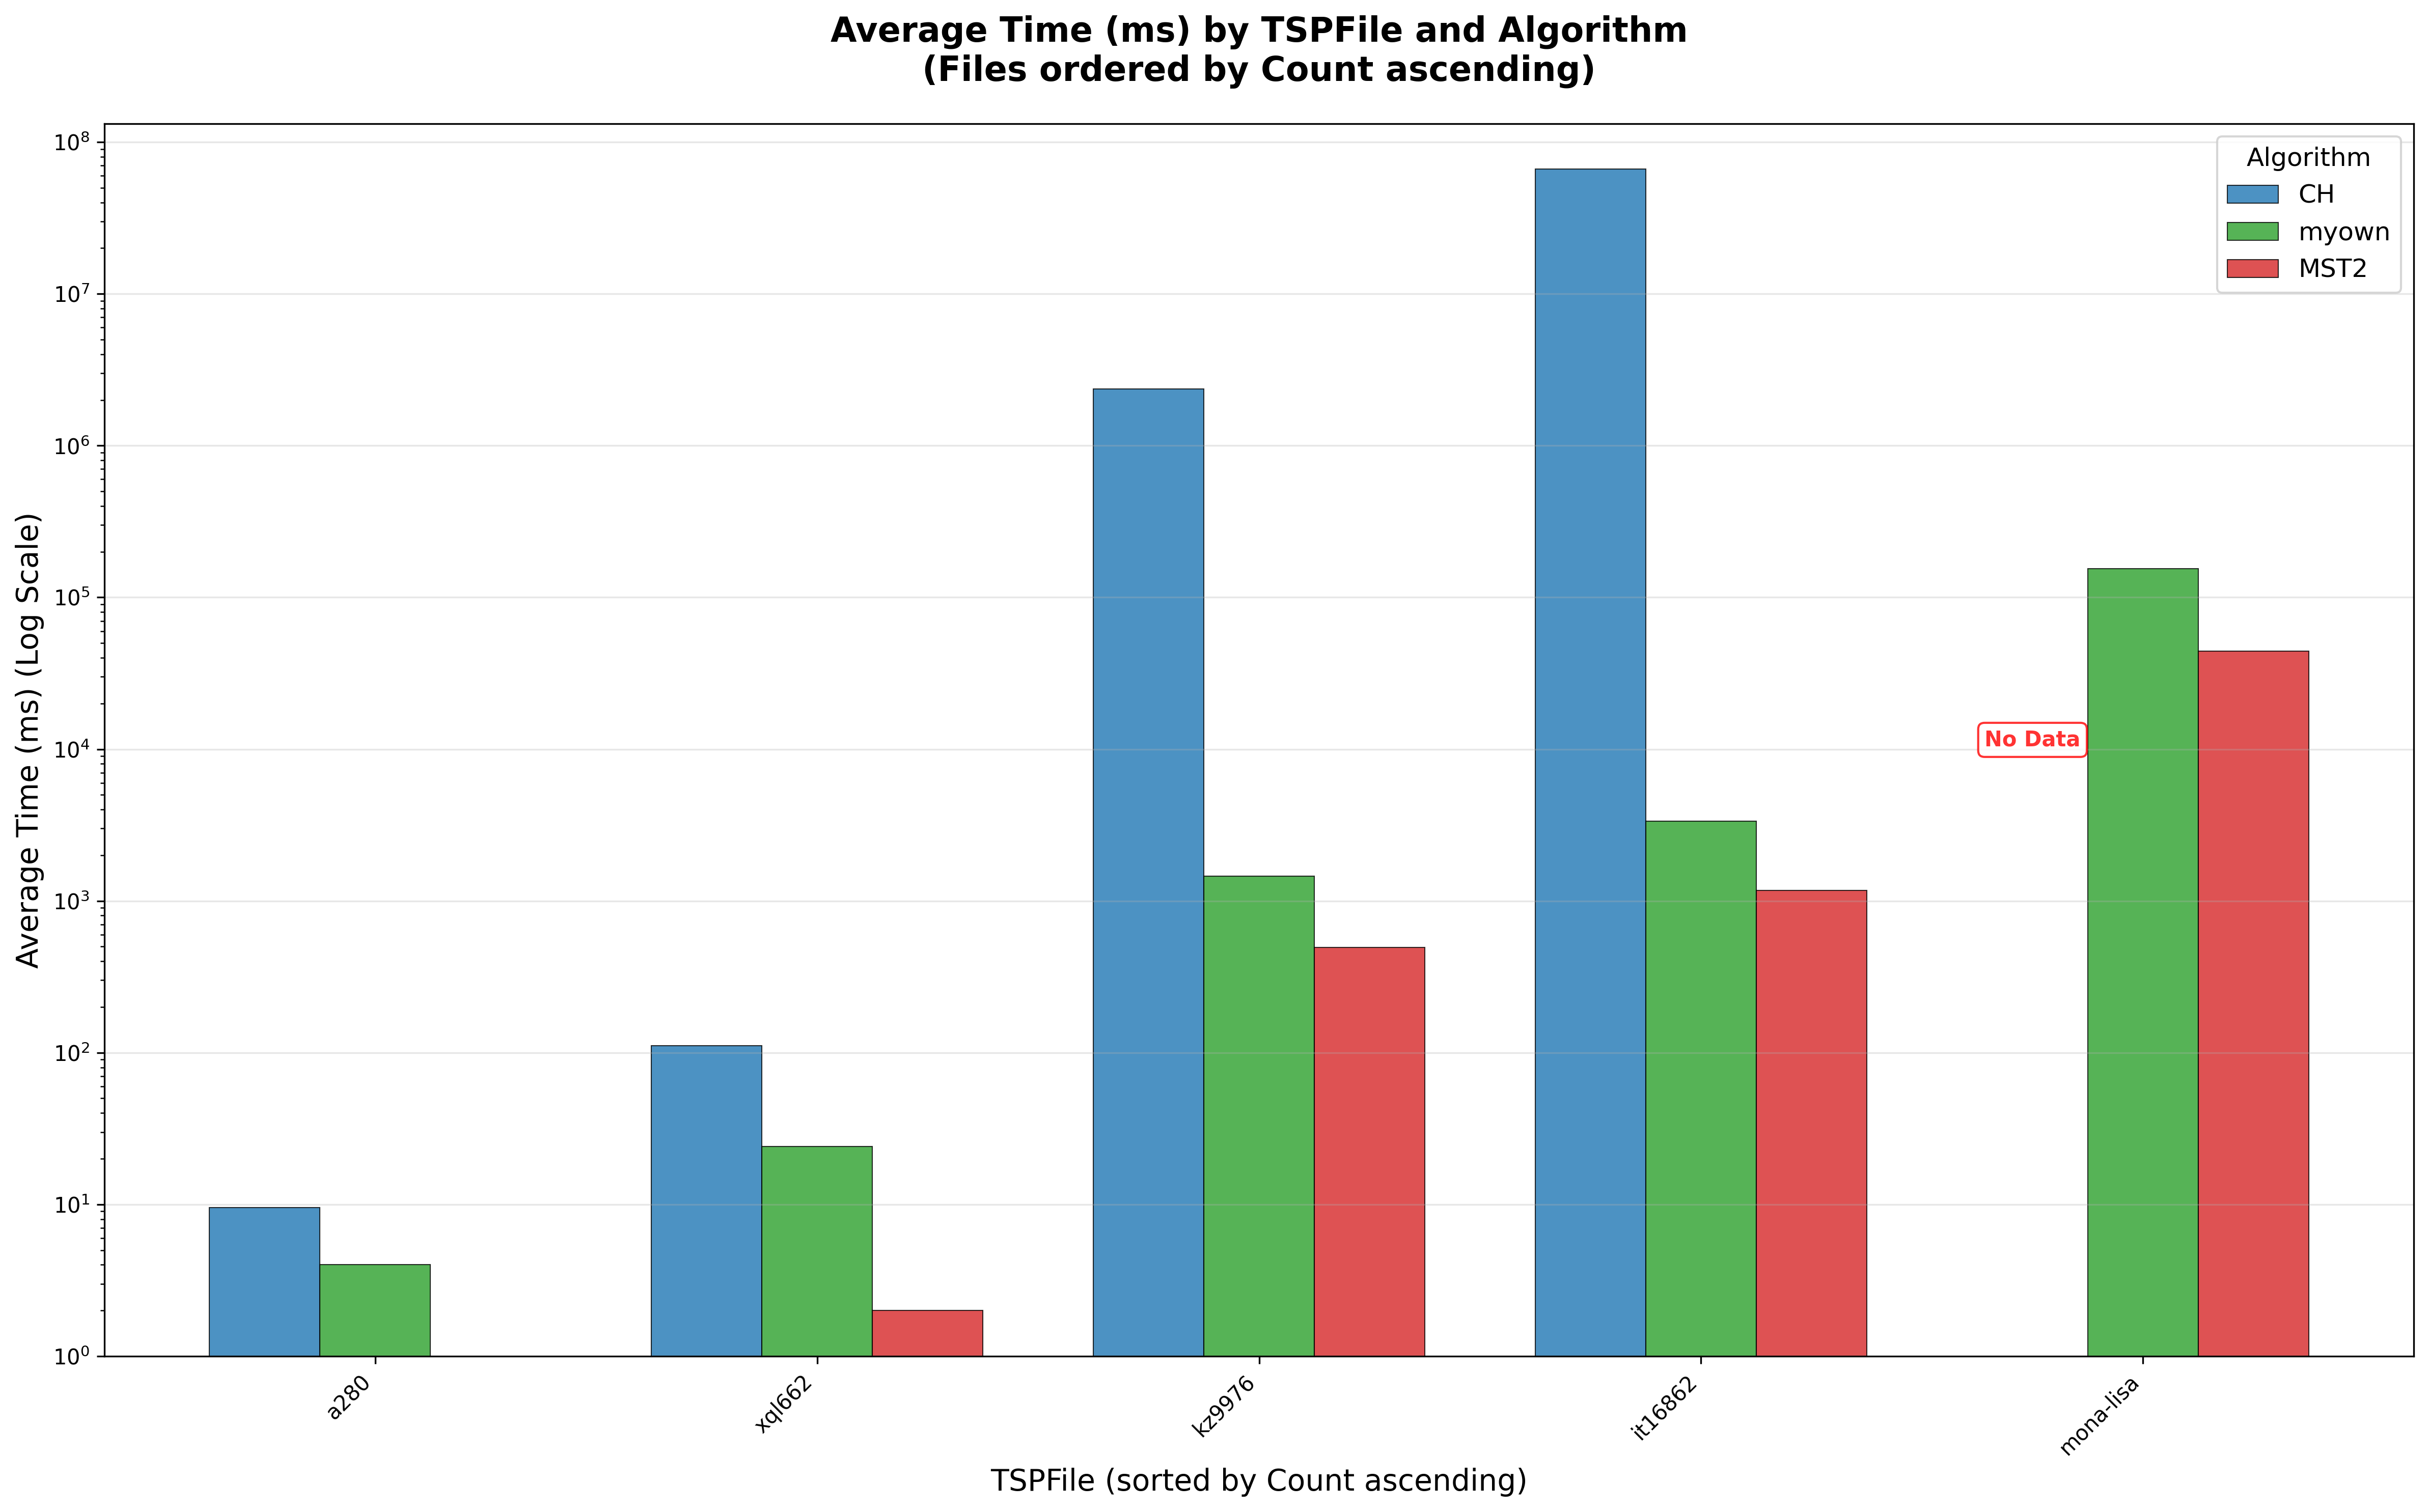

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

bar_time.png 다운로드 완료!
AverageMemory(MB): 로그 스케일 적용 (범위: 3.75 ~ 3728.98)


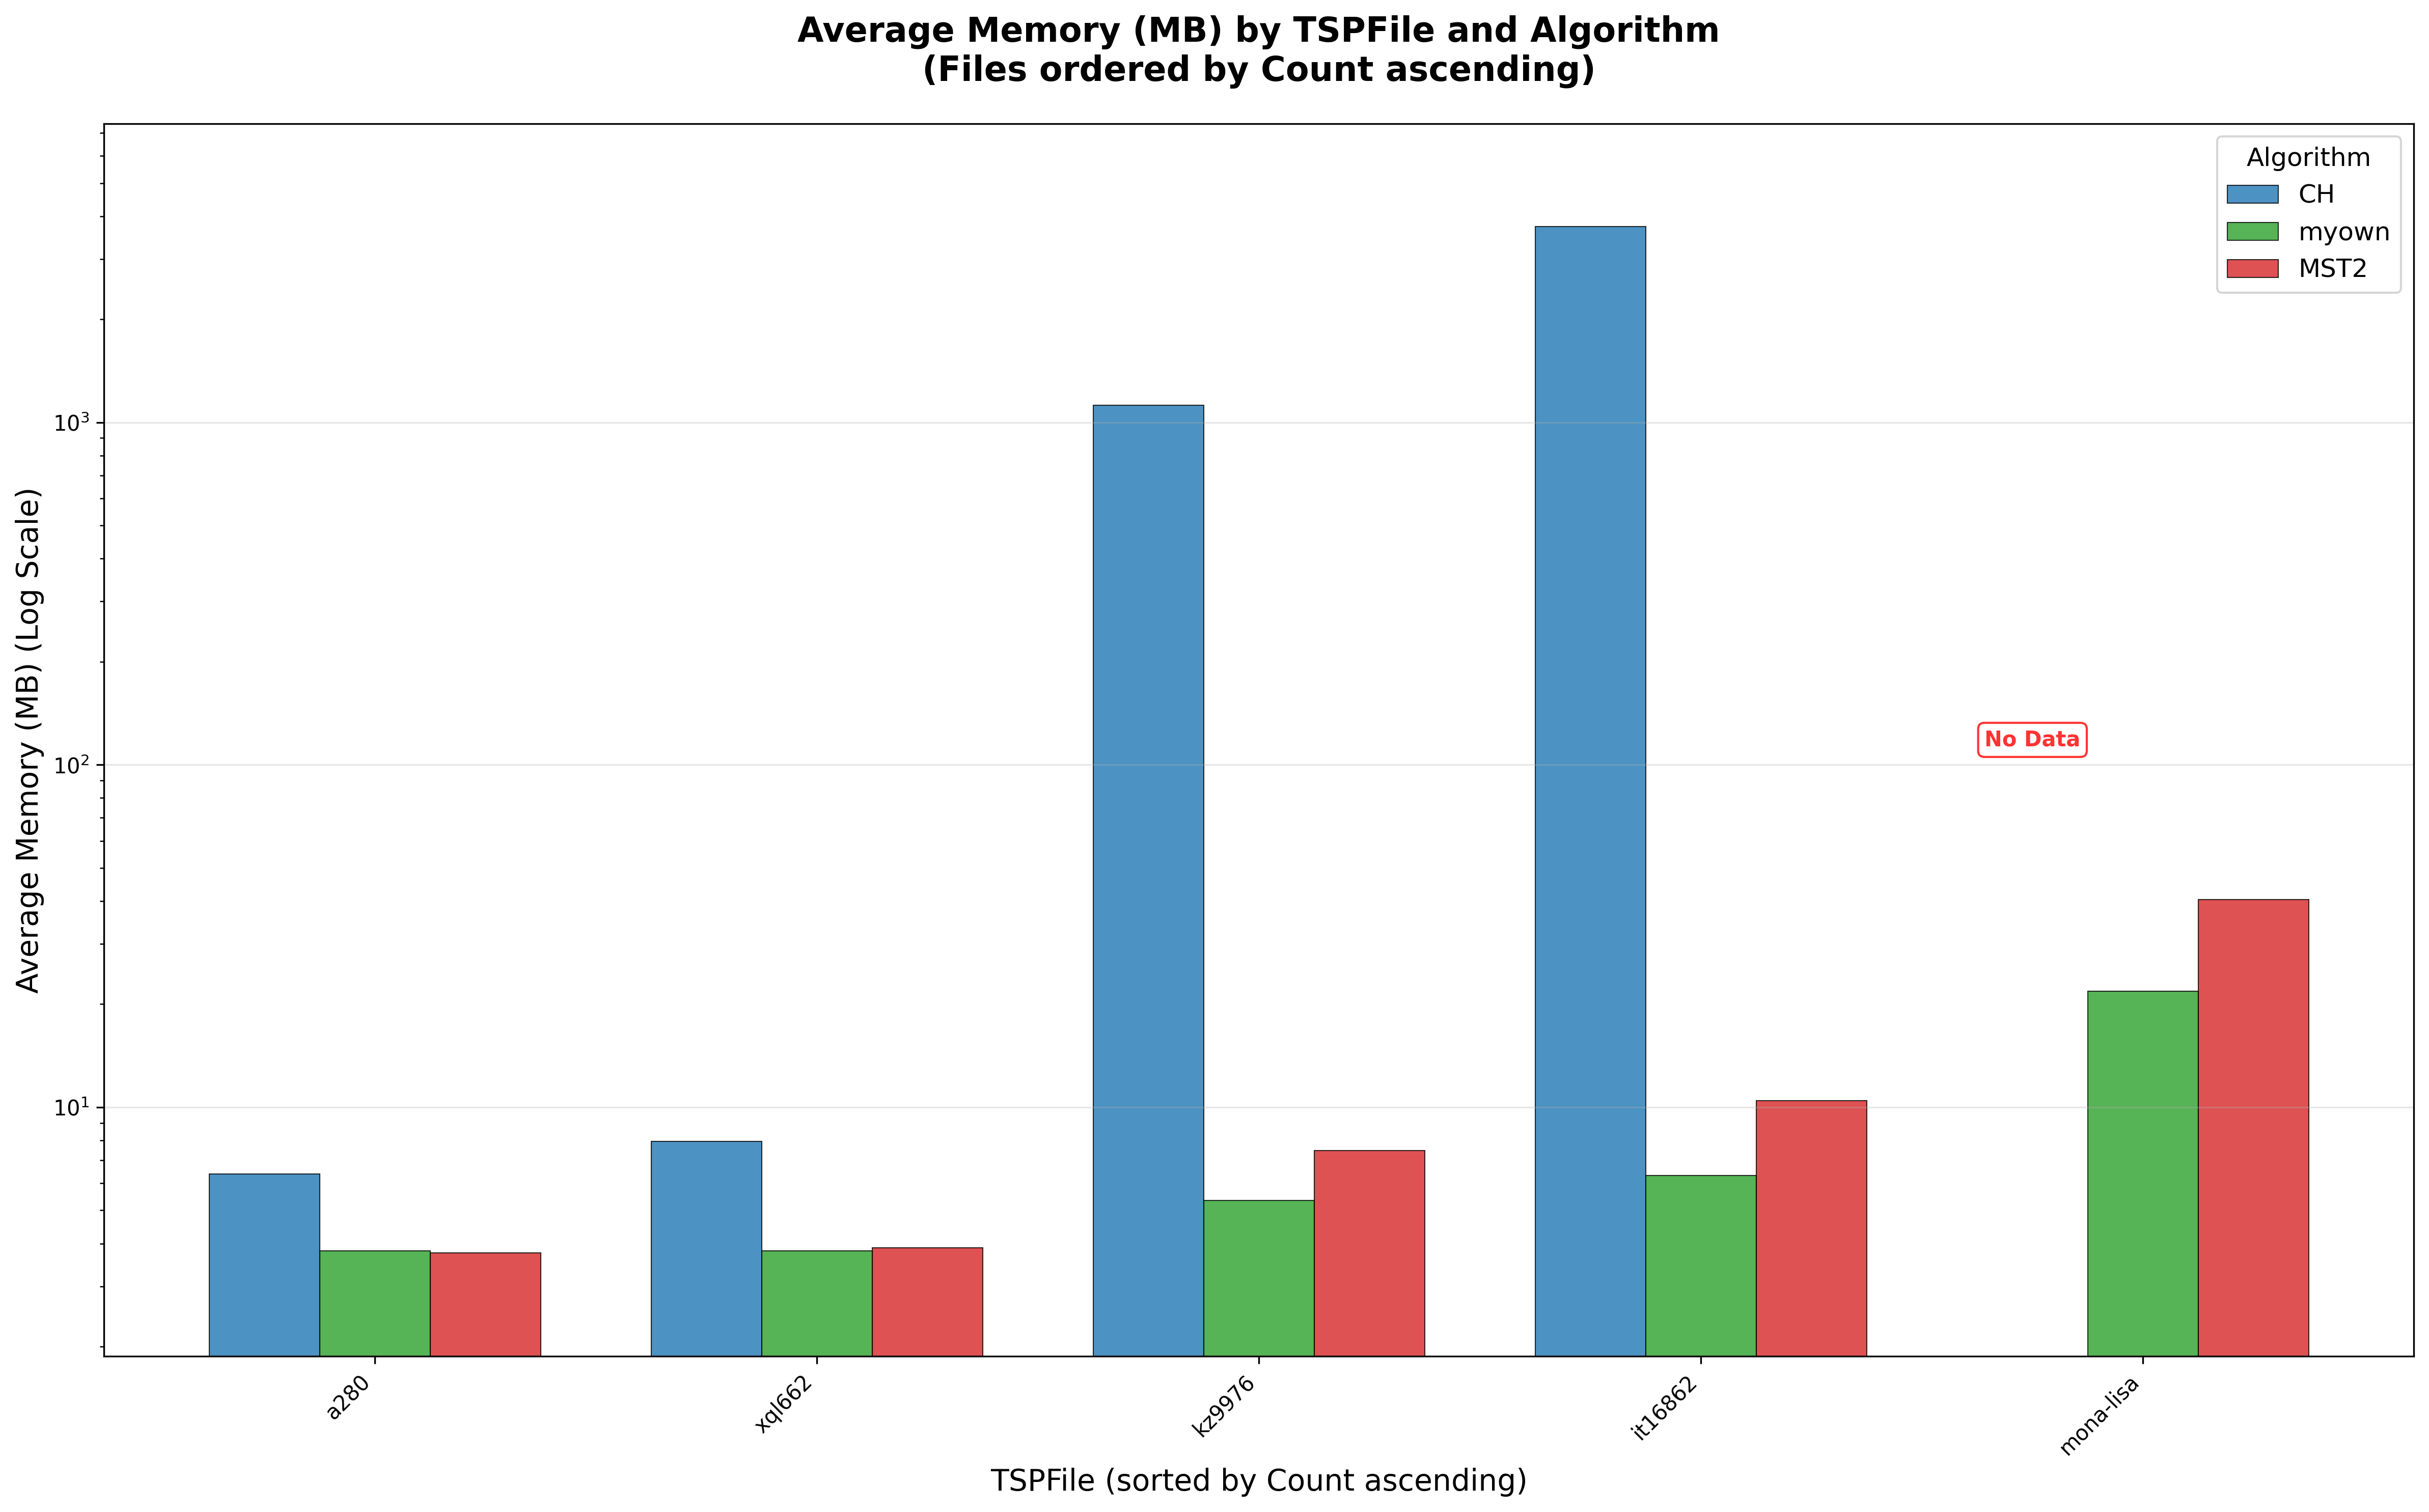

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

bar_mem.png 다운로드 완료!
AverageResult: 로그 스케일 적용 (범위: 2847.00 ~ 8322297.00)


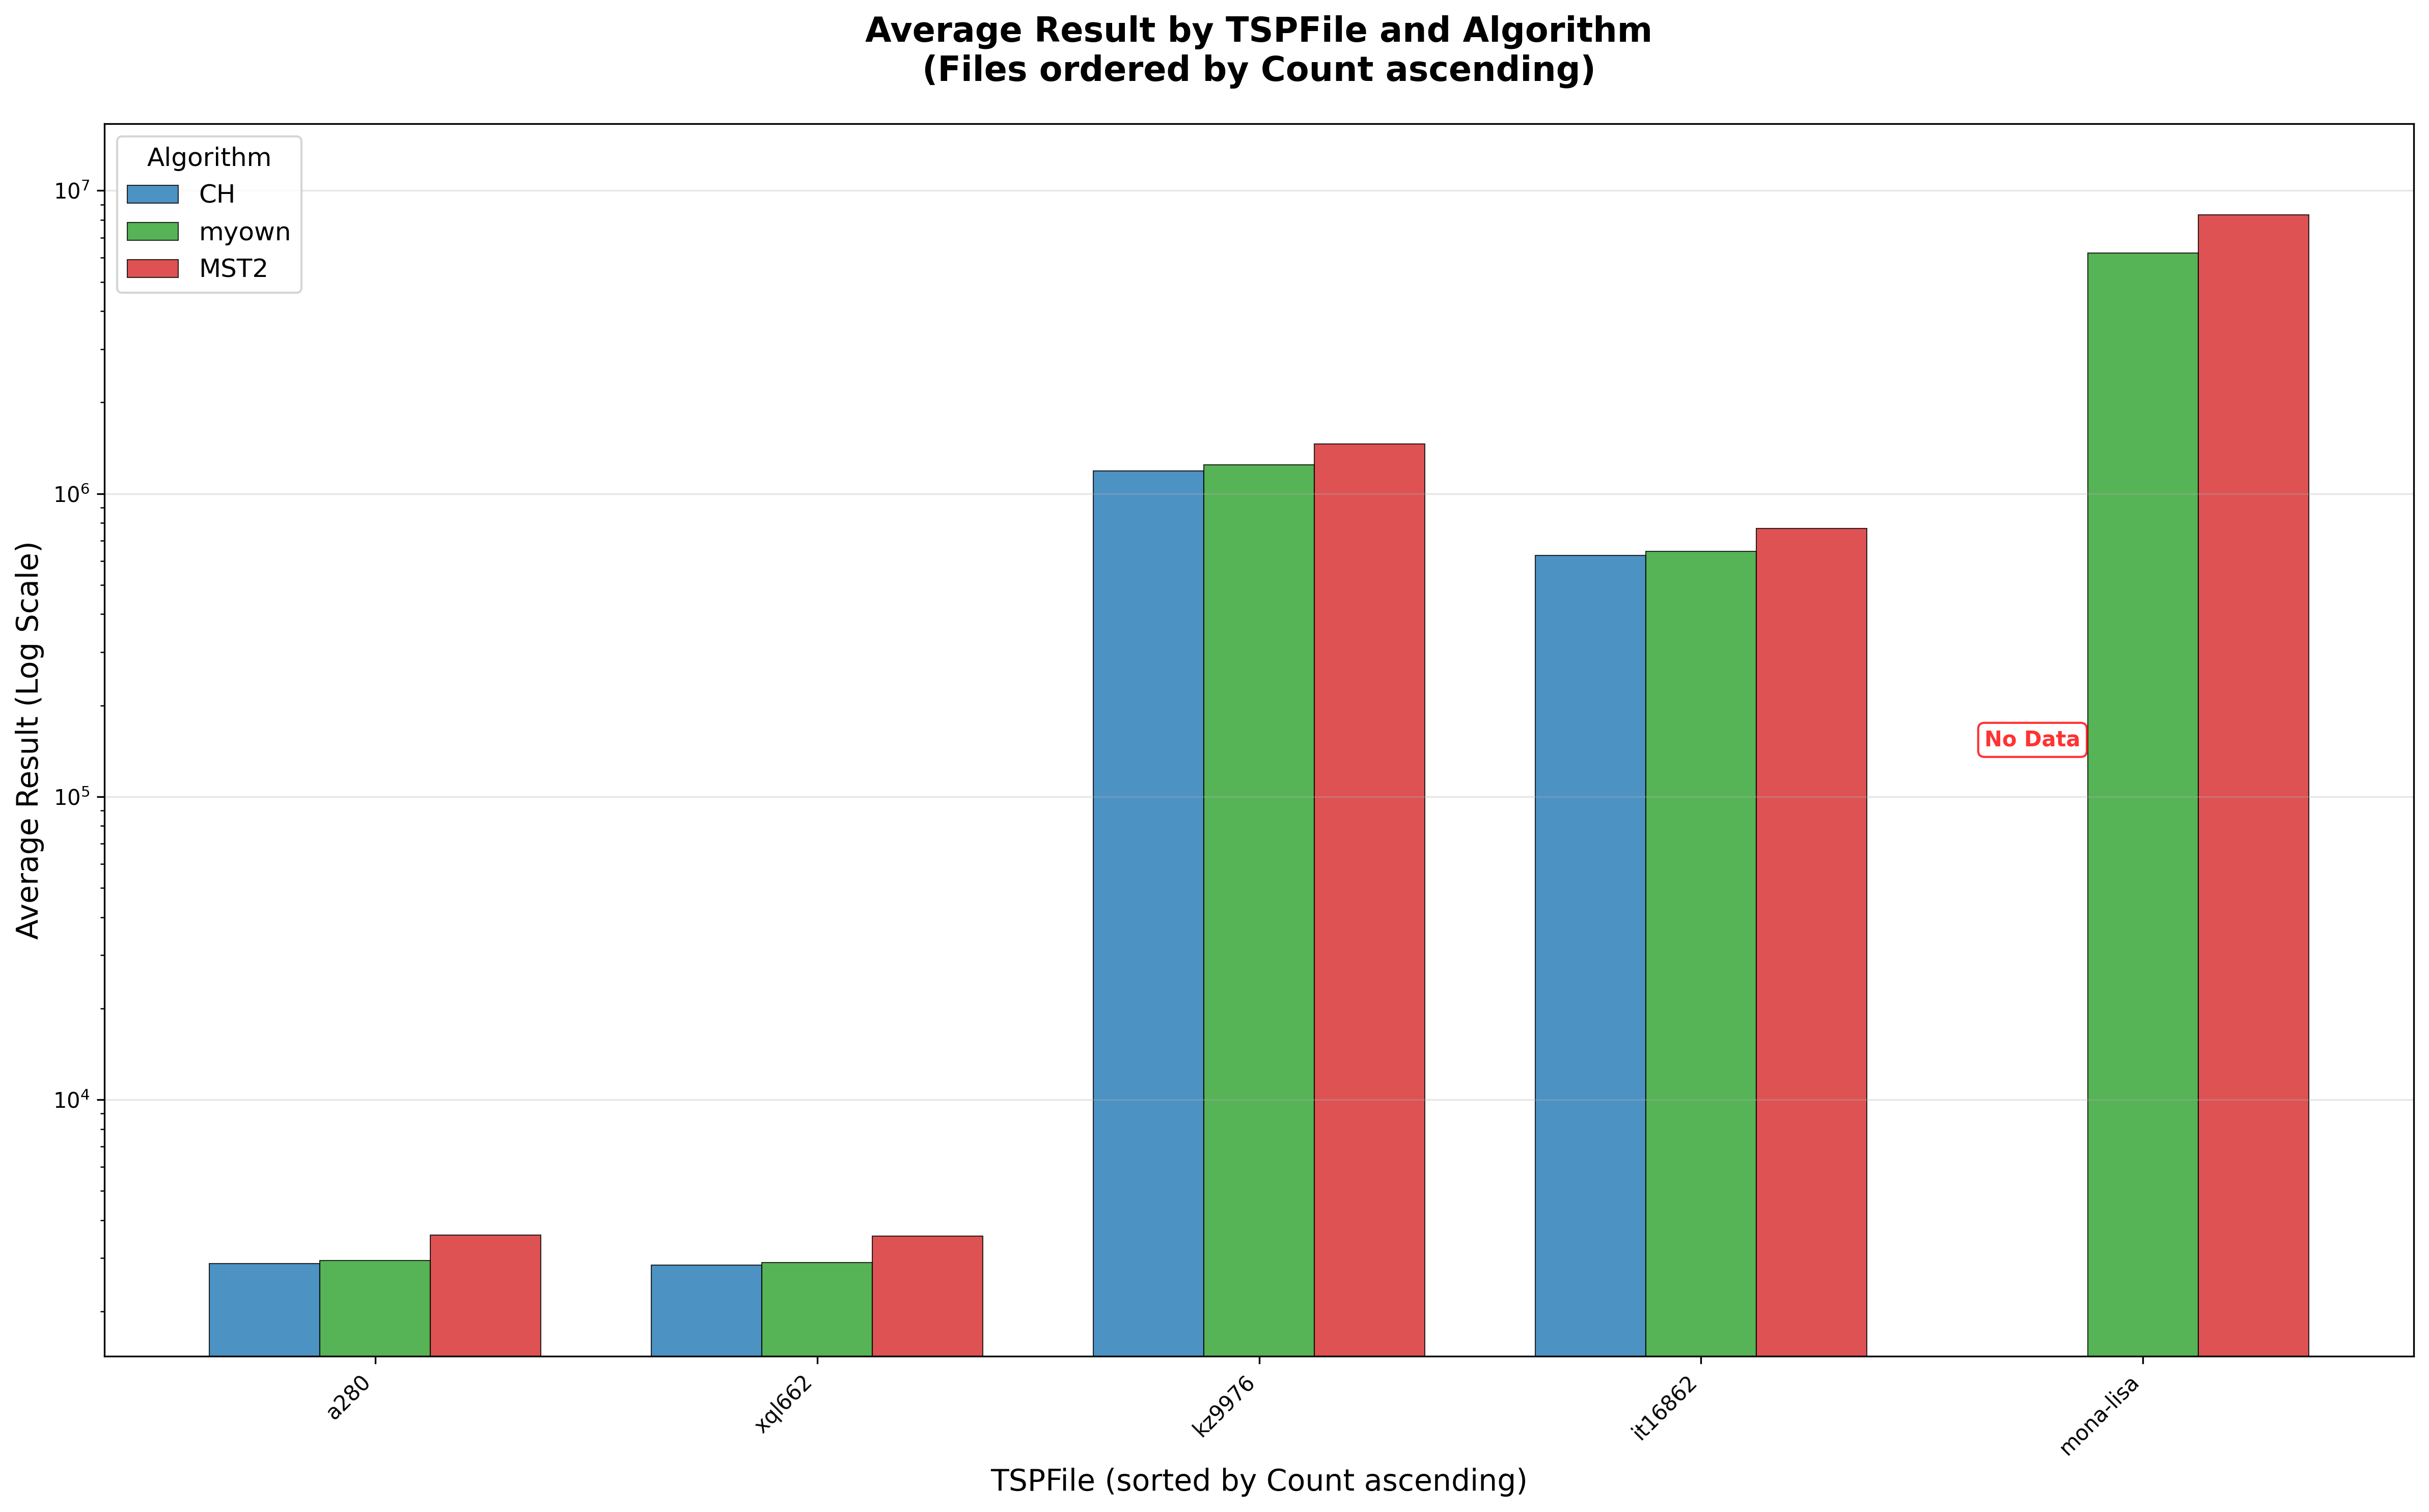

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

bar_result.png 다운로드 완료!

=== 데이터 요약 ===

파일별 Count 정보:
  a280.tsp: 280
  xql662.tsp: 662
  kz9976.tsp: 9,976
  it16862.tsp: 16,862
  mona-lisa100K.tsp: 100,000

각 알고리즘별 데이터 존재 여부:

CH:
  ✓ a280.tsp: 데이터 있음
  ✓ xql662.tsp: 데이터 있음
  ✓ kz9976.tsp: 데이터 있음
  ✓ it16862.tsp: 데이터 있음
  ✗ mona-lisa100K.tsp: 데이터 없음

myown:
  ✓ a280.tsp: 데이터 있음
  ✓ xql662.tsp: 데이터 있음
  ✓ kz9976.tsp: 데이터 있음
  ✓ it16862.tsp: 데이터 있음
  ✓ mona-lisa100K.tsp: 데이터 있음

MST2:
  ✓ a280.tsp: 데이터 있음
  ✓ xql662.tsp: 데이터 있음
  ✓ kz9976.tsp: 데이터 있음
  ✓ it16862.tsp: 데이터 있음
  ✓ mona-lisa100K.tsp: 데이터 있음

=== 성능 비교 분석 ===

【AverageTime(ms)】

  a280.tsp:
    CH    :         9.50
    myown :         4.00
    MST2  :         0.00
    → 최고 성능: MST2

  xql662.tsp:
    CH    :       111.00
    myown :        24.00
    MST2  :         2.00
    → 최고 성능: MST2

  kz9976.tsp:
    CH    : 2,361,986.00
    myown :     1,452.00
    MST2  :       493.00
    → 최고 성능: MST2

  it16862.tsp:
    CH    : 66,207,403.00
    myown :     3,348.50
    MST2  :

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# CSV 파일들 읽기
ch_df = pd.read_csv('CH_16862.csv')
myown_df = pd.read_csv('myown_100000.csv')
mst2_df = pd.read_csv('MST2_100000.csv')

# 소스 컬럼 추가
ch_df['Source'] = 'CH'
myown_df['Source'] = 'myown'
mst2_df['Source'] = 'MST2'

# 모든 데이터 결합
combined_df = pd.concat([ch_df, myown_df, mst2_df], ignore_index=True)

print("=== 데이터 로드 완료 ===")
print(f"CH 데이터: {len(ch_df)}개")
print(f"myown 데이터: {len(myown_df)}개")
print(f"MST2 데이터: {len(mst2_df)}개")

# CH에 없는 mona-lisa100K.tsp 데이터를 NaN으로 추가
if 'mona-lisa100K.tsp' not in ch_df['TSPFile'].values:
    mona_lisa_row = pd.DataFrame({
        'Algorithm': ['basic_CH'],
        'TSPFile': ['mona-lisa100K.tsp'],
        'StartIndex': [0],
        'Count': [100000],
        'AverageTime(ms)': [np.nan],
        'AverageMemory(MB)': [np.nan],
        'AverageResult': [np.nan],
        'Source': ['CH']
    })
    combined_df = pd.concat([combined_df, mona_lisa_row], ignore_index=True)

# TSPFile을 Count 기준으로 정렬
file_order = combined_df.groupby('TSPFile')['Count'].min().sort_values().index.tolist()
print(f"\n파일 정렬 순서 (Count 기준): {file_order}")

# 그래프 설정
metrics = ['AverageTime(ms)', 'AverageMemory(MB)', 'AverageResult']
filenames = ['bar_time.png', 'bar_mem.png', 'bar_result.png']
titles = ['Average Time (ms)', 'Average Memory (MB)', 'Average Result']
source_colors = {'CH': '#1f77b4', 'myown': '#2ca02c', 'MST2': '#d62728'}  # 파란색, 초록색, 빨간색

# 각 메트릭별로 그래프 생성
for metric, filename, title in zip(metrics, filenames, titles):
    plt.figure(figsize=(16, 10), dpi=300)

    # x축 위치 설정
    x_positions = np.arange(len(file_order))
    width = 0.25

    # 로그 스케일 적용 여부 미리 결정
    non_zero_values = [v for v in combined_df[metric].dropna() if v > 0]
    use_log_scale = False
    if non_zero_values and len(non_zero_values) > 1:
        max_val = max(non_zero_values)
        min_val = min(non_zero_values)
        if max_val / min_val > 100:  # 100배 이상 차이나면 로그 스케일 적용
            use_log_scale = True
            print(f"{metric}: 로그 스케일 적용 (범위: {min_val:.2f} ~ {max_val:.2f})")

    # 각 소스별로 바 그래프 그리기
    for i, source in enumerate(['CH', 'myown', 'MST2']):
        values = []
        for file in file_order:
            file_data = combined_df[(combined_df['TSPFile'] == file) & (combined_df['Source'] == source)]
            if len(file_data) > 0:
                value = file_data[metric].iloc[0]
                # NaN인 경우 0으로 처리 (시각적으로 막대가 보이지 않음)
                values.append(0 if pd.isna(value) else value)
            else:
                values.append(0)

        # 바 그래프 그리기
        bars = plt.bar(x_positions + (i - 1) * width, values, width,
                      label=source, color=source_colors[source], alpha=0.8,
                      edgecolor='black', linewidth=0.5)

        # 값이 0인 막대에 "No Data" 표시 (그래프 영역 내에서)
        for j, (bar, value) in enumerate(zip(bars, values)):
            if value == 0 and source == 'CH' and file_order[j] == 'mona-lisa100K.tsp':
                # y축 범위의 중간 지점에 텍스트 배치
                if use_log_scale:
                    # 로그 스케일인 경우 기하평균 사용
                    text_y = np.sqrt(min_val * max_val) if min_val > 0 else max_val * 0.1
                else:
                    # 선형 스케일인 경우 산술평균 사용
                    text_y = max_val * 0.5 if max_val > 0 else 1

                plt.text(bar.get_x() + bar.get_width()/2, text_y,
                        'No Data', ha='center', va='center', fontsize=10,
                        rotation=0, alpha=0.8, color='red', fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                                edgecolor="red", alpha=0.8))

    # 그래프 설정
    plt.title(f'{title} by TSPFile and Algorithm\n(Files ordered by Count ascending)',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('TSPFile (sorted by Count ascending)', fontsize=14)

    # 로그 스케일 적용
    if use_log_scale:
        plt.yscale('log')
        plt.ylabel(f'{title} (Log Scale)', fontsize=14)
    else:
        plt.ylabel(title, fontsize=14)

    # x축 라벨 설정 (파일명에서 .tsp 제거)
    file_labels = []
    for file in file_order:
        label = file.replace('.tsp', '').replace('mona-lisa100K', 'mona-lisa')
        file_labels.append(label)

    plt.xticks(x_positions, file_labels, rotation=45, ha='right')
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend(title='Algorithm', fontsize=12, title_fontsize=12)

    # y축 범위를 명시적으로 설정하여 "No Data" 텍스트가 그래프 영역 내에 오도록 함
    if use_log_scale and min_val > 0:
        plt.ylim(min_val * 0.5, max_val * 2)
    elif not use_log_scale and max_val > 0:
        plt.ylim(0, max_val * 1.1)

    plt.tight_layout()

    # 파일 저장 및 표시
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    # Google Colab에서 파일 다운로드
    files.download(filename)
    print(f"{filename} 다운로드 완료!")

# 데이터 요약 출력
print("\n" + "="*60)
print("=== 데이터 요약 ===")
print("="*60)

print("\n파일별 Count 정보:")
for file in file_order:
    count = combined_df[combined_df['TSPFile'] == file]['Count'].iloc[0]
    print(f"  {file}: {count:,}")

print("\n각 알고리즘별 데이터 존재 여부:")
for source in ['CH', 'myown', 'MST2']:
    print(f"\n{source}:")
    for file in file_order:
        file_data = combined_df[(combined_df['TSPFile'] == file) & (combined_df['Source'] == source)]
        if len(file_data) > 0 and not pd.isna(file_data['AverageTime(ms)'].iloc[0]):
            print(f"  ✓ {file}: 데이터 있음")
        else:
            print(f"  ✗ {file}: 데이터 없음")

print("\n" + "="*60)
print("=== 성능 비교 분석 ===")
print("="*60)

for metric in metrics:
    print(f"\n【{metric}】")
    for file in file_order:
        print(f"\n  {file}:")
        values = {}
        for source in ['CH', 'myown', 'MST2']:
            file_data = combined_df[(combined_df['TSPFile'] == file) & (combined_df['Source'] == source)]
            if len(file_data) > 0:
                value = file_data[metric].iloc[0]
                if pd.isna(value):
                    print(f"    {source:6}: 데이터 없음")
                    values[source] = None
                else:
                    print(f"    {source:6}: {value:>12,.2f}")
                    values[source] = value

        # 성능 순위 (값이 있는 것만)
        valid_values = {k: v for k, v in values.items() if v is not None}
        if len(valid_values) > 1:
            if metric == 'AverageTime(ms)' or metric == 'AverageMemory(MB)':
                # 시간과 메모리는 낮을수록 좋음
                best = min(valid_values, key=valid_values.get)
                print(f"    → 최고 성능: {best}")
            else:
                # Result는 낮을수록 좋음 (TSP 문제)
                best = min(valid_values, key=valid_values.get)
                print(f"    → 최고 성능: {best}")

print("\n" + "="*60)
print("그래프 생성 및 다운로드가 완료되었습니다!")
print("생성된 파일: bar_time.png, bar_mem.png, bar_result.png")
print("="*60)
